In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms.functional
from torchvision.transforms import ToTensor
import PIL.Image
from tqdm import tqdm
import os

# Finally, a useful function that we do not explicitly use, but you can check out if you want
# from torchsummary import summary # courtesy of https://stackoverflow.com/questions/55875279/how-to-get-an-output-dimension-for-each-layer-of-the-neural-network-in-pytorch


# Collects the Data and implementing the CNN

All the code below was taken from a previous course which is Signals and Data, the reason for this is because we know that the CNN will work here and  we can therefore modify the CNN to sample the most uncertant data.

In [2]:
# This code is from the coyrse Signals and Data

# Check if you have cuda available, and use if you do
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Set a random seed for everything important
def seed_everything(seed: int):
    import random
    import os
    import numpy as np
    import torch
    
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = False

# Set a seed with a random integer, in this case, I choose my verymost favourite sequence of numbers
seed_everything(sum([115, 107, 105, 98, 105, 100, 105, 32, 116, 111, 105, 108, 101, 116]))


cpu


In [ ]:
# The code below is from the course Signals and Data

# Load a dataset, change 'dataset' to 'mnist' if you want to use MNIST instead
from pathlib import Path

dataset = 'cifar10'
data_root = Path('data')
if not data_root.exists():
    data_root = Path('Assignment 2 - MJ') / 'data'
data_root.mkdir(parents=True, exist_ok=True)

if dataset == 'cifar10':
    train_set = datasets.CIFAR10(root=str(data_root), train=True, download=True, transform=ToTensor())
    test_set = datasets.CIFAR10(root=str(data_root), train=False, download=True, transform=ToTensor())

    # Purely for our convenience - Mapping from cifar labels to human readable classes
    cifar10_classes = {
        0: 'airplane',
        1: 'automobile',
        2: 'bird',
        3: 'cat',
        4: 'deer',
        5: 'dog',
        6: 'frog',
        7: 'horse',
        8: 'ship',
        9: 'truck'
    }

elif dataset == 'mnist':
    train_set = datasets.MNIST(root=str(data_root), train=True, download=True, transform=ToTensor())
    test_set = datasets.MNIST(root=str(data_root), train=False, download=True, transform=ToTensor())

print(f"There are {len(train_set)} examples in the training set")
print(f"There are {len(test_set)} examples in the test set \n")

print(f"Image shape is: {train_set[0][0].shape}, label example is {train_set[0][1]}")


In [4]:
# This code is from the course Signals and Data

# Collate function is called on each batch, the dataloader yields
# Here, we modify it to also cast the tensors to our desired device
from torch.utils.data.dataloader import default_collate


def collate_fn(batch):
    inputs, targets = default_collate(batch)
    return inputs.to(device), targets.to(device)


# Why don't we shuffle the test set? Because we don't need to.
train_dataloader = torch.utils.data.DataLoader(
    train_set, batch_size=16, shuffle=True, collate_fn=collate_fn
)
test_dataloader = torch.utils.data.DataLoader(
    test_set, batch_size=16, shuffle=False, collate_fn=collate_fn
)


In [5]:
# This code is from the course Signals and Data

class CNN(torch.nn.Module):
    def __init__(
        self,
        num_classes,
        in_channels=3,
        features_before_linear=None,
        features_fore_linear=None,
        lr=0.001,
        lambda_reg=0.0,
        device=None,
    ):
        super().__init__()
        self.lambda_reg = lambda_reg
        self.device = torch.device(device) if device is not None else torch.device("cpu")

        # Support both spellings used elsewhere in the notebook.
        if features_before_linear is None:
            features_before_linear = features_fore_linear

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        if features_before_linear is None:
            sample_input = torch.zeros(1, in_channels, 32, 32)
            features_before_linear = self.feature_extractor(sample_input).numel()

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=features_before_linear, out_features=600),
            nn.ReLU(),
            nn.Linear(in_features=600, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=num_classes),
        )

        self.layers = nn.Sequential(self.feature_extractor, self.classifier)
        self.to(self.device)

        self.criterion = nn.CrossEntropyLoss()
        self.optim = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=lambda_reg)

    def forward(self, x):
        """
        Perform a forward pass using the model

        Args:
            x (torch.tensor): Tensor to be passed through the model's layers. Shape should fit with the initial layer of the model.

        Returns: torch.tensor of the result of passing x through the model's layers
        """
        x = x.to(self.device)
        return self.layers(x)

    def fit(self, train_dataloader, epochs=1, val_dataloader=None):
        """
        Train the model

        Args:
            train_dataloader (iterable): Some iterable that yields tuples of (inputs, targets)
            ... each inputs should of shape (b, c, n, m) where b is the batch size, c is the number of channels, and n, m are the input image dimensions
            ... each targets should be of shape (b) with integers corresponding to the index of the correct class
            ... all values yielded from the train_dataloader should be torch tensors
            epochs (int): An integer representing how many epochs (total runthroughs of the data) the model should train for. Defaults to 1.
            val_dataloader (Optional, iterable): An iterable of the same type as train_dataloader. If set, the model will test itself after each train epoch

        Returns:
            train_accs, val_accs (list[float], list[float]): Lists containing floats of the training- and validation-accuracy respectively after each epoch.
        """
        train_accs = []
        val_accs = []

        for epoch in range(epochs):
            self.train()
            epoch_correct = 0

            for inputs, targets in tqdm(train_dataloader):
                inputs = inputs.to(self.device)
                targets = targets.to(self.device)

                self.optim.zero_grad()
                outputs = self(inputs)
                loss = self.criterion(outputs, targets)
                loss.backward()
                self.optim.step()

                epoch_correct += (torch.argmax(outputs, dim=1) == targets).sum().item()

            train_acc = epoch_correct / len(train_dataloader.dataset)
            train_accs.append(train_acc)

            if val_dataloader is not None:
                acc = self.evaluate(val_dataloader)
                val_accs.append(acc)
                print(f"Epoch {epoch + 1}: train accuracy = {train_acc:.4f}, validation accuracy = {acc:.4f}")

        return train_accs, val_accs

    @torch.no_grad()
    def evaluate(self, test_dataloader):
        self.eval()
        total_correct = 0

        for input_batch, label_batch in test_dataloader:
            input_batch = input_batch.to(self.device)
            label_batch = label_batch.to(self.device)
            logits = self(input_batch)
            classifications = torch.argmax(logits, dim=1)
            total_correct += (classifications == label_batch).sum().item()

        return total_correct / len(test_dataloader.dataset)

    def save_model(self, model_name):
        if not os.path.exists("saved_models"):
            os.makedirs("saved_models")
        save_path = os.path.join("saved_models", model_name)
        torch.save(self.state_dict(), save_path)
        print(f"Model successfully saved at {save_path}")

    def load_model(self, model_name):
        model_path = os.path.join("saved_models", model_name)
        self.load_state_dict(torch.load(model_path, map_location=self.device))
        self.to(self.device)
        print(f"Model state_dict successfully loaded from {model_path}")


# Cross validation to find the best suatiable reguarlization term

In [6]:
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader,Subset

In [7]:
def cross_validation_lambda(
    dataset,
    lambda_grid,
    k_folds=5,
    epochs=5,
    batch_size=64,
    num_classes=10,
    in_channels=3,
    features_before_linear=None,
    lr=0.001,
    device="cpu",
):
    if isinstance(dataset, str):
        raise TypeError("cross_validation_lambda expects a dataset object, not a dataset name string.")

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    indices = np.arange(len(dataset))
    lambda_results = {}

    for lambda_reg in lambda_grid:
        fold_acc = []
        print(f"\nTesting lambda = {lambda_reg}")

        for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)

            train_load = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
            val_load = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

            model = CNN(
                num_classes=num_classes,
                in_channels=in_channels,
                features_before_linear=features_before_linear,
                lr=lr,
                lambda_reg=lambda_reg,
                device=device,
            )

            model.fit(train_load, epochs=epochs)
            val_acc = model.evaluate(val_load)
            fold_acc.append(val_acc)

            print(f"Fold {fold}: validation accuracy = {val_acc:.4f}")

        mean_acc = float(np.mean(fold_acc))
        std_acc = float(np.std(fold_acc))
        lambda_results[lambda_reg] = {
            "mean_val_acc": mean_acc,
            "mean_val_std": std_acc,
        }

        print(f"Lambda {lambda_reg}: mean={mean_acc:.4f}, std={std_acc:.4f}")

    best_lambda = max(lambda_results, key=lambda x: lambda_results[x]["mean_val_acc"])
    return best_lambda, lambda_results


In [8]:
best_lambda, lambda_results = cross_validation_lambda(
    dataset=train_set,
    lambda_grid=[0.0, 1e-5, 1e-4, 1e-3, 1e-2],
    k_folds=5,
    epochs=5,
    batch_size=64,
    num_classes=10,
    in_channels=3,
    features_before_linear=None,
    lr=0.001,
    device=device,
)

print("Best lambda:", best_lambda)
print(lambda_results)



Testing lambda = 0.0


100%|██████████| 625/625 [00:33<00:00, 18.41it/s]


Fold 1: validation accuracy = 0.6944


100%|██████████| 625/625 [00:33<00:00, 18.67it/s]


Fold 2: validation accuracy = 0.6809


...

Fold 3: validation accuracy = 0.5254


100%|██████████| 625/625 [04:49<00:00,  2.16it/s]


Fold 4: validation accuracy = 0.5090


100%|██████████| 625/625 [03:02<00:00,  3.42it/s]


Fold 5: validation accuracy = 0.5092
Lambda 0.01: mean=0.5133, std=0.0061
Best lambda: 1e-05
{0.0: {'mean_val_acc': 0.6955199999999999, 'mean_val_std': 0.008523238821011652}, 1e-05: {'mean_val_acc': 0.7000200000000001, 'mean_val_std': 0.005874827657046629}, 0.0001: {'mean_val_acc': 0.69024, 'mean_val_std': 0.005229378548164213}, 0.001: {'mean_val_acc': 0.64412, 'mean_val_std': 0.019813873927124907}, 0.01: {'mean_val_acc': 0.5133399999999999, 'mean_val_std': 0.006147389689941568}}


# Uncertainty sampling and random sampling

In [12]:
# Random sampling:
def random_sampling(unlabeled_indices, query_size):
    query_size = min(query_size, len(unlabeled_indices))
    return np.random.choice(unlabeled_indices, size=query_size, replace=False)


# Uncertainty sampling:
@torch.no_grad()
def uncertainty_sampling(model, dataset, unlabeled_indices, query_size, batch_size=64):
    query_size = min(query_size, len(unlabeled_indices))
    unlabeled_subset = Subset(dataset, unlabeled_indices)
    unlabeled_load = DataLoader(unlabeled_subset, batch_size=batch_size, shuffle=False)

    was_training = model.training
    model.eval()
    uncertainties = []
    offset = 0

    for x, _ in unlabeled_load:
        x = x.to(model.device)
        logits = model(x)
        probabilities = torch.softmax(logits, dim=1)
        max_probability, _ = torch.max(probabilities, dim=1)
        batch_uncertainty = 1 - max_probability

        for i, u in enumerate(batch_uncertainty.cpu().numpy()):
            uncertainties.append((unlabeled_indices[offset + i], float(u)))

        offset += len(x)

    if was_training:
        model.train()

    uncertainties.sort(key=lambda t: t[1], reverse=True)
    selected = [idx for idx, _ in uncertainties[:query_size]]
    return np.array(selected)


# Active learning loop

In [17]:
def active_learning_experiment(
    train_dataset,
    test_dataset,
    initial_labeled_size,
    query_size,
    n_rounds,
    sampling_method,   # "random" or "uncertainty"
    lambda_reg,
    batch_size=64,
    epochs=10,
    num_classes=10,
    in_channels=3,
    features_before_linear=None,
    lr=0.001,
    device="cpu",
):
    all_indices = np.arange(len(train_dataset))
    np.random.shuffle(all_indices)

    labeled_indices = list(all_indices[:initial_labeled_size])
    unlabeled_indices = list(all_indices[initial_labeled_size:])

    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    performance_history = []

    for round_idx in range(n_rounds):
        print(f"\nRound {round_idx + 1}/{n_rounds}")

        labeled_subset = Subset(train_dataset, labeled_indices)
        train_loader = DataLoader(labeled_subset, batch_size=batch_size, shuffle=True)

        model = CNN(
            num_classes=num_classes,
            in_channels=in_channels,
            features_before_linear=features_before_linear,
            lr=lr,
            lambda_reg=lambda_reg,
            device=device,
        )

        model.fit(train_loader, epochs=epochs)
        test_acc = model.evaluate(test_loader)
        performance_history.append(test_acc)

        print(f"Test accuracy: {test_acc:.4f}")
        print(f"Labeled samples: {len(labeled_indices)}")

        if round_idx == n_rounds - 1 or len(unlabeled_indices) == 0:
            break

        if sampling_method == "random":
            selected = random_sampling(unlabeled_indices, query_size)
        elif sampling_method == "uncertainty":
            selected = uncertainty_sampling(
                model,
                train_dataset,
                unlabeled_indices,
                query_size,
                batch_size=batch_size,
            )
        else:
            raise ValueError("sampling_method must be 'random' or 'uncertainty'")

        selected = list(map(int, selected))
        selected_set = set(selected)
        labeled_indices.extend(selected)
        unlabeled_indices = [idx for idx in unlabeled_indices if idx not in selected_set]

    return performance_history


# Comparing the uncertainty sampling and the random sampling

In [21]:
# Use the best lambda selected above.

random_history = active_learning_experiment(
    train_dataset=train_set,
    test_dataset=test_set,
    initial_labeled_size=2000,
    query_size=50,
    n_rounds=10,
    sampling_method="random",
    lambda_reg=best_lambda,
    batch_size=64,
    epochs=10,
    num_classes=10,
    in_channels=3,
    features_before_linear=None,
    lr=0.001,
    device=device,
)

us_history = active_learning_experiment(
    train_dataset=train_set,
    test_dataset=test_set,
    initial_labeled_size=2000,
    query_size=50,
    n_rounds=10,
    sampling_method="uncertainty",
    lambda_reg=best_lambda,
    batch_size=64,
    epochs=10,
    num_classes=10,
    in_channels=3,
    features_before_linear=None,
    lr=0.001,
    device=device,
)

print("Random sampling history:", random_history)
print("Uncertainty sampling history:", us_history)



Round 1/10


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [00:01<00:00, 30.59it/s]


Test accuracy: 0.4410
Labeled samples: 2000

Round 2/10


100%|██████████| 33/33 [00:01<00:00, 26.42it/s]


...

Test accuracy: 0.4888
Labeled samples: 2350

Round 9/10


100%|██████████| 38/38 [00:01<00:00, 23.47it/s]


Test accuracy: 0.4841
Labeled samples: 2400

Round 10/10


100%|██████████| 39/39 [00:01<00:00, 23.08it/s]


Test accuracy: 0.4789
Labeled samples: 2450
Random sampling history: [0.441, 0.435, 0.4584, 0.434, 0.4725, 0.4809, 0.4809, 0.4596, 0.4786, 0.4884]
Uncertainty sampling history: [0.4683, 0.4423, 0.4713, 0.4833, 0.4696, 0.4954, 0.4629, 0.4888, 0.4841, 0.4789]


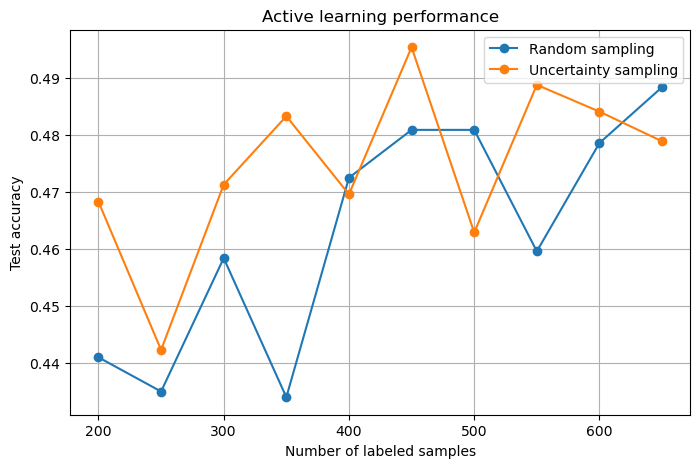

In [22]:
import matplotlib.pyplot as plt

initial_labeled_size = 200
query_size = 50

rounds = np.arange(1, len(random_history) + 1)
labeled_counts = [initial_labeled_size + i * query_size for i in range(len(random_history))]

plt.figure(figsize=(8,5))
plt.plot(labeled_counts, random_history, marker='o', label='Random sampling')
plt.plot(labeled_counts, us_history, marker='o', label='Uncertainty sampling')
plt.xlabel("Number of labeled samples")
plt.ylabel("Test accuracy")
plt.title("Active learning performance")
plt.legend()
plt.grid(True)
plt.show()